In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## Loading dataset

In [2]:
df = pd.read_csv("hiring.csv")
print(df)

  experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0        NaN                    8.0                           9      50000
1        NaN                    8.0                           6      45000
2       five                    6.0                           7      60000
3        two                   10.0                          10      65000
4      seven                    9.0                           6      70000
5      three                    7.0                          10      62000
6        ten                    NaN                           7      72000
7     eleven                    7.0                           8      80000


## Cleaning dataset

In [3]:
words = {"zero": 0, "one": 1, "two": 2, "three": 3, "four": 4, "five": 5, "six": 6,
         "seven": 7, "eight": 8, "nine": 9, "ten": 10, "eleven": 11, "twelve": 12}

df["experience"] = df["experience"].replace(words).fillna(0).astype(float)   # words -> numbers, NaN -> 0

test = "test_score(out of 10)"
df[test] = df[test].fillna(df[test].median())                                # missing score -> median


## Features (X) and target (y)

In [4]:
X = df[["experience", test, "interview_score(out of 10)"]]
y = df["salary($)"]

## Model Training

In [5]:
model = LinearRegression()
model.fit(X, y)

print("Coefficients:", dict(zip(X.columns, model.coef_.round(2))))
print("Intercept   :", round(model.intercept_, 2))
print("R2          :", round(model.score(X, y), 3))


Coefficients: {'experience': np.float64(2812.95), 'test_score(out of 10)': np.float64(1845.71), 'interview_score(out of 10)': np.float64(2205.24)}
Intercept   : 17737.26
R2          : 0.962


## Prediction for new candidates

In [6]:
new = pd.DataFrame({"experience": [2, 12],
                    test: [9, 10],
                    "interview_score(out of 10)": [6, 10]})
new["predicted_salary($)"] = model.predict(new).round(2)
print(new)

   experience  test_score(out of 10)  interview_score(out of 10)  \
0           2                      9                           6   
1          12                     10                          10   

   predicted_salary($)  
0             53205.97  
1             92002.18  


## Graph: actual vs predicted salary 

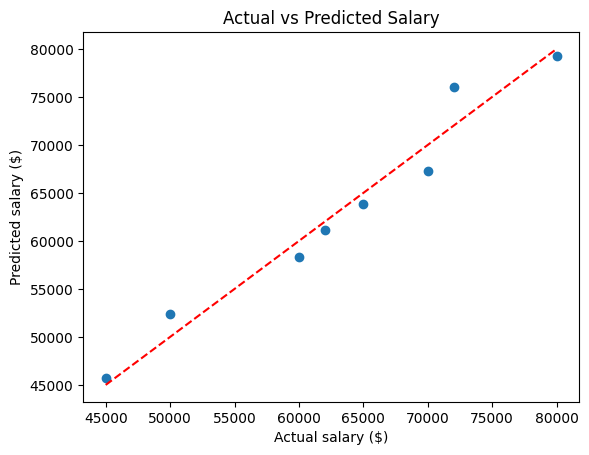

In [7]:
plt.scatter(y, model.predict(X))
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")   # perfect prediction line
plt.xlabel("Actual salary ($)"); plt.ylabel("Predicted salary ($)")
plt.title("Actual vs Predicted Salary")
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()